## 1. Setup, data location, and subsampling

The loader accepts any of: extracted Kaggle files (`rating.csv` / `movie.csv`), the Kaggle
`archive.zip` itself next to this notebook, or the official GroupLens `ml-20m/` layout
(`ratings.csv` / `movies.csv`), and normalizes both timestamp formats.

In [1]:
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import svds
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

SEED = 42
N_USERS = 4_000            # size of the user subsample — the one knob to turn
MIN_MOVIE_RATINGS = 5      # drop movies with fewer ratings than this *within the subsample*
CHUNK_SIZE = 2_000_000     # rows per chunk when streaming the 20M-row file

sns.set_theme(style="whitegrid")


def locate_ml20m():
    """Find the 20M data: extracted Kaggle files, official layout, or a zip archive."""
    for base in (Path("."), Path("ml-20m")):
        if (base / "rating.csv").exists() and (base / "movie.csv").exists():
            return "files", base / "rating.csv", base / "movie.csv"
        if (base / "ratings.csv").exists() and (base / "genome-scores.csv").exists():
            return "files", base / "ratings.csv", base / "movies.csv"
    for z in ("archive.zip", "ml-20m.zip"):
        if Path(z).exists():
            with zipfile.ZipFile(z) as zf:
                names = zf.namelist()
            rat = next(n for n in names if n.endswith(("rating.csv", "ratings.csv")))
            mov = next(n for n in names if n.endswith(("movie.csv", "movies.csv")))
            return "zip", (z, rat), (z, mov)
    raise FileNotFoundError(
        "Place the MovieLens 20M data next to this notebook: either the Kaggle "
        "archive.zip, or extracted rating.csv + movie.csv (or the official ml-20m folder)."
    )


SRC_KIND, RATING_SRC, MOVIE_SRC = locate_ml20m()
print(f"data source: {SRC_KIND} -> {RATING_SRC}")


def read_ratings(**kwargs):
    if SRC_KIND == "files":
        return pd.read_csv(RATING_SRC, **kwargs)
    zpath, member = RATING_SRC
    return pd.read_csv(zipfile.ZipFile(zpath).open(member), **kwargs)


def read_movies():
    if SRC_KIND == "files":
        return pd.read_csv(MOVIE_SRC)
    zpath, member = MOVIE_SRC
    return pd.read_csv(zipfile.ZipFile(zpath).open(member))

data source: files -> ml-20m/rating.csv


**Pass 1** loads only the three numeric columns (≈ 240 MB instead of ≈ 1.6 GB with
timestamps), computes a few full-data statistics for the EDA, and draws the user sample.

In [2]:
t0 = time.time()
raw = read_ratings(usecols=["userId", "movieId", "rating"],
                   dtype={"userId": np.int32, "movieId": np.int32, "rating": np.float32})
print(f"loaded {len(raw):,} ratings | {raw['userId'].nunique():,} users | "
      f"{raw['movieId'].nunique():,} movies | global mean {raw['rating'].mean():.4f} "
      f"| {time.time() - t0:.0f}s")

# full-data aggregates kept for the EDA section
full_rating_counts = raw["rating"].value_counts().sort_index()
full_movie_counts = raw["movieId"].value_counts()

rng = np.random.default_rng(SEED)
sampled_users = np.sort(rng.choice(raw["userId"].unique(), size=N_USERS, replace=False))
sub = raw.loc[np.isin(raw["userId"].to_numpy(), sampled_users)].copy()
del raw
print(f"subsample: {len(sub):,} ratings from {N_USERS:,} users "
      f"on {sub['movieId'].nunique():,} movies")

loaded 20,000,263 ratings | 138,493 users | 26,744 movies | global mean 3.5255 | 6s


subsample: 579,893 ratings from 4,000 users on 13,346 movies


**Pass 2** streams the file again in chunks to pick up timestamps for *only* the sampled
users, verifies row alignment, then applies the movie-frequency filter.

In [3]:
t0 = time.time()
parts = []
for chunk in read_ratings(usecols=["userId", "timestamp"], dtype={"userId": np.int32},
                          chunksize=CHUNK_SIZE):
    parts.append(chunk.loc[np.isin(chunk["userId"].to_numpy(), sampled_users)])
ts = pd.concat(parts, ignore_index=True)
del parts
assert (ts["userId"].to_numpy() == sub["userId"].to_numpy()).all(), "row alignment failed"

if pd.api.types.is_numeric_dtype(ts["timestamp"]):          # official GroupLens format
    sub["timestamp"] = pd.to_datetime(ts["timestamp"].to_numpy(), unit="s")
else:                                                        # Kaggle format
    sub["timestamp"] = pd.to_datetime(ts["timestamp"].to_numpy(),
                                      format="%Y-%m-%d %H:%M:%S")
del ts
print(f"timestamps attached and verified in {time.time() - t0:.0f}s")

movie_counts_sub = sub["movieId"].value_counts()
n_sub = len(sub)
ratings = sub[sub["movieId"].isin(
    movie_counts_sub.index[movie_counts_sub >= MIN_MOVIE_RATINGS])].copy()
del sub

movies_all = read_movies()
movies = (movies_all[movies_all["movieId"].isin(ratings["movieId"].unique())]
          .reset_index(drop=True))
print(f"after movie filter (>= {MIN_MOVIE_RATINGS} ratings in subsample): "
      f"{len(ratings):,} ratings ({len(ratings) / n_sub:.1%} of subsample kept) "
      f"on {len(movies):,} movies")
ratings.head()

timestamps attached and verified in 9s
after movie filter (>= 5 ratings in subsample): 568,926 ratings (98.1% of subsample kept) on 7,359 movies


,userId,movieId,rating,timestamp
8016,71,318,5.0,2014-12-01 17:13:35
8017,71,356,5.0,2014-12-01 17:16:58
8018,71,1704,5.0,2014-12-01 17:17:03
8019,71,1721,4.5,2014-12-01 17:19:17
8020,71,2019,4.5,2014-12-01 17:19:50


## 2. Exploratory data analysis

Rating distribution and most-rated movies use **all 20M ratings**; the remaining plots
describe the subsample the models are trained on.

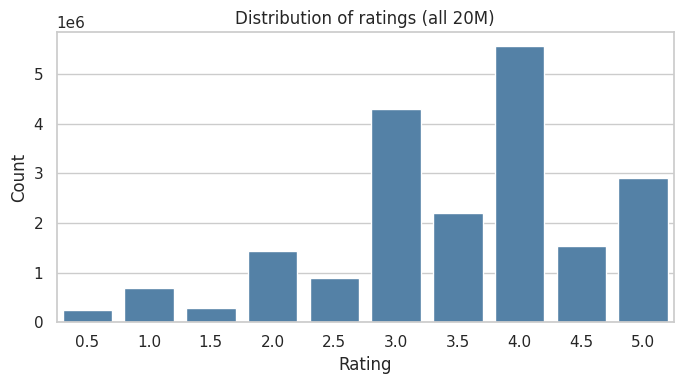

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=full_rating_counts.index.astype(str), y=full_rating_counts.values,
            color="steelblue", ax=ax)
ax.set(title="Distribution of ratings (all 20M)", xlabel="Rating", ylabel="Count")
plt.tight_layout()
plt.show()

Ratings skew positive (mode 4.0). Half-star ratings only exist after 2003, which is why
whole stars dominate. Later we call a held-out movie "relevant" if rated ≥ 4.0.

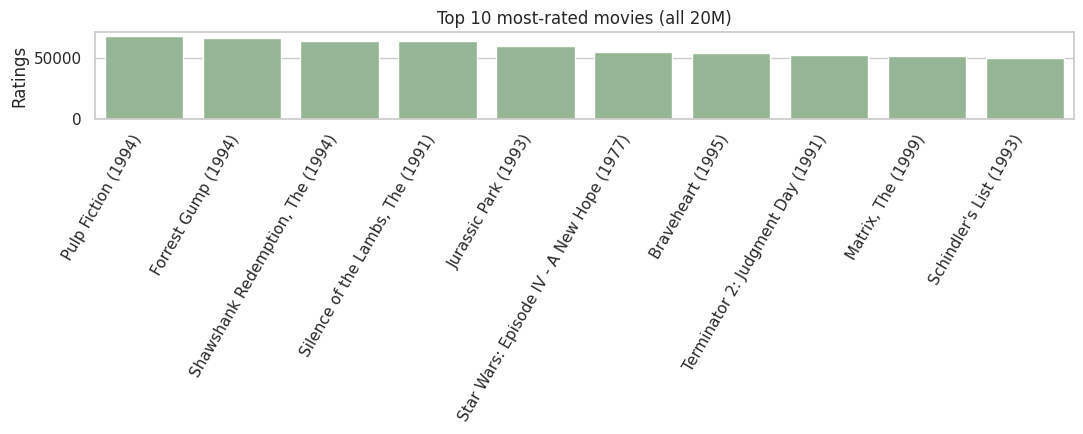

In [5]:
top10 = (full_movie_counts.head(10).rename("num_ratings").reset_index()
         .merge(movies_all[["movieId", "title"]], on="movieId"))

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=top10, x="title", y="num_ratings", color="darkseagreen", ax=ax)
ax.set(title="Top 10 most-rated movies (all 20M)", xlabel=None, ylabel="Ratings")
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
plt.tight_layout()
plt.show()

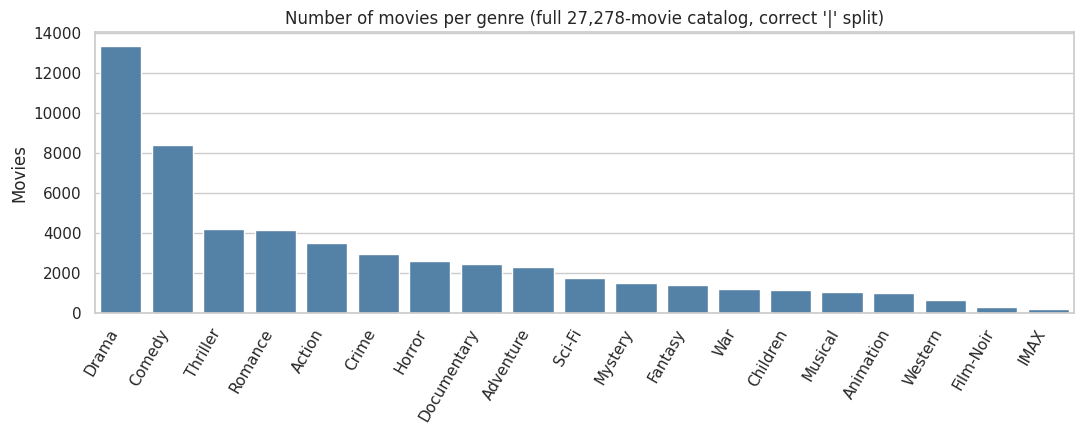

In [6]:
genre_counts = (movies_all["genres"].str.split("|").explode()
                .value_counts().drop("(no genres listed)"))

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(x=genre_counts.index, y=genre_counts.values, color="steelblue", ax=ax)
ax.set(title="Number of movies per genre (full 27,278-movie catalog, correct '|' split)",
       xlabel=None, ylabel="Movies")
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
plt.tight_layout()
plt.show()

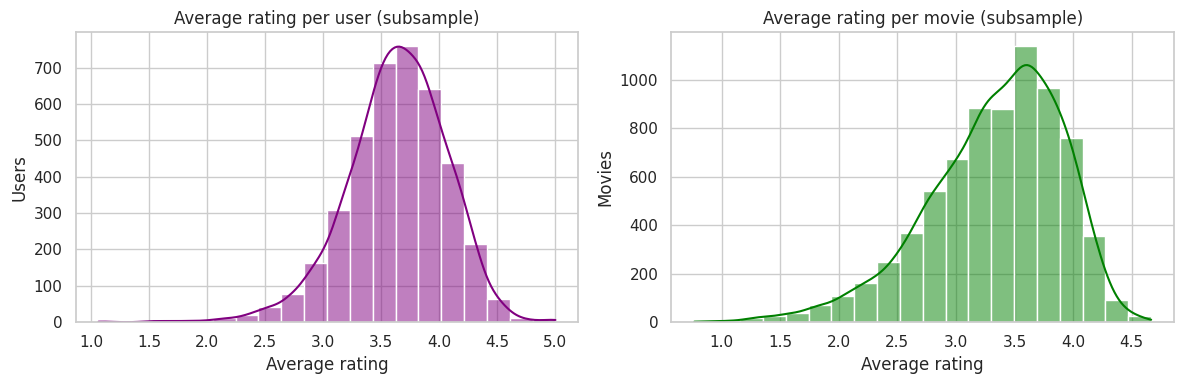

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(ratings.groupby("userId")["rating"].mean(), bins=20, kde=True,
             color="purple", ax=axes[0])
axes[0].set(title="Average rating per user (subsample)", xlabel="Average rating",
            ylabel="Users")
sns.histplot(ratings.groupby("movieId")["rating"].mean(), bins=20, kde=True,
             color="green", ax=axes[1])
axes[1].set(title="Average rating per movie (subsample)", xlabel="Average rating",
            ylabel="Movies")
plt.tight_layout()
plt.show()

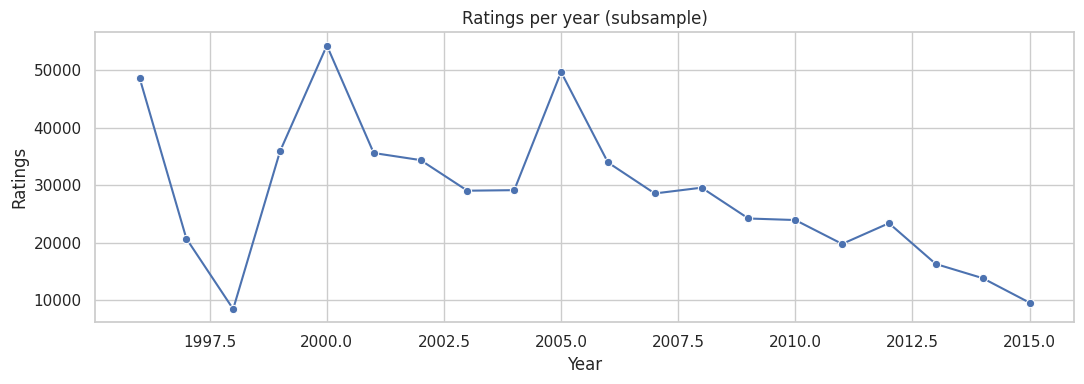

In [8]:
per_year = ratings["timestamp"].dt.year.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(x=per_year.index, y=per_year.values, marker="o", ax=ax)
ax.set(title="Ratings per year (subsample)", xlabel="Year", ylabel="Ratings")
plt.tight_layout()
plt.show()

Popularity is heavily long-tailed (the top-10 chart alone shows single movies with > 60k
ratings while the median movie has a handful). Consequences for modeling: per-item
estimates need **regularization**, and we report **catalog coverage** so a recommender is
not judged only on how well it pushes blockbusters.

## 3. Train / validation / test split (80 / 10 / 10)

The **validation** set is for choosing hyperparameters (number of latent factors `k`,
hybrid weight α). The **test** set is used exactly once, at the very end, so the final
numbers are an honest estimate of generalization.

In [9]:
train_val, test = train_test_split(ratings, test_size=0.10, random_state=SEED)
train, val = train_test_split(train_val, test_size=1 / 9, random_state=SEED)  # 1/9 of 90% = 10%
print(f"train: {len(train):,}   val: {len(val):,}   test: {len(test):,}")


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

train: 455,140   val: 56,893   test: 56,893


## 4. Rating-prediction baselines

Any model has to beat these to justify its complexity. The **bias model** is the classic
damped-means baseline (Koren, 2010): $\hat r_{ui} = \mu + b_u + b_i$, where the user and item
offsets are shrunk toward zero by a damping term so that rarely-rated movies/users do not get
extreme estimates.

In [10]:
def fit_baselines(fit_df, damping=10.0):
    """Return {name: predict_fn} for four reference predictors fit on `fit_df`."""
    mu = fit_df["rating"].mean()
    user_mean = fit_df.groupby("userId")["rating"].mean()
    item_mean = fit_df.groupby("movieId")["rating"].mean()

    ist = fit_df.groupby("movieId")["rating"].agg(["sum", "count"])
    b_i = (ist["sum"] - mu * ist["count"]) / (ist["count"] + damping)
    resid = fit_df["rating"] - mu - fit_df["movieId"].map(b_i)
    ust = resid.groupby(fit_df["userId"]).agg(["sum", "count"])
    b_u = ust["sum"] / (ust["count"] + damping)

    return {
        "Global mean": lambda df: np.full(len(df), mu),
        "User mean": lambda df: df["userId"].map(user_mean).fillna(mu).to_numpy(),
        "Item mean": lambda df: df["movieId"].map(item_mean).fillna(mu).to_numpy(),
        "Bias model (mu+bu+bi)": lambda df: np.clip(
            mu + df["movieId"].map(b_i).fillna(0) + df["userId"].map(b_u).fillna(0),
            0.5, 5.0).to_numpy(),
    }


baselines = fit_baselines(train)
val_scores = {name: rmse(val["rating"], predict(val)) for name, predict in baselines.items()}
pd.Series(val_scores, name="validation RMSE").round(4).to_frame()

,validation RMSE
Global mean,1.0457
User mean,0.9662
Item mean,0.9447
Bias model (mu+bu+bi),0.8705


## 5. Why v1's SVD failed (RMSE ≈ 3.17)

v1 built a dense user×item matrix, filled every unrated cell with **0**, and demeaned each user
across **all** columns. Each user rates only a tiny fraction of the catalog, so that
"user mean" collapses toward 0 instead of ≈ 3.5, and the truncated SVD spends its
capacity reconstructing the zeros.
Predictions for unseen movies therefore land near 0 on a 0.5–5 scale. It also explains why
v1's RMSE *increased* with `k`: more factors reconstruct the zero-filled matrix — and hence
the zeros — more faithfully. Reproduced on our split:

In [11]:
M = train.pivot(index="userId", columns="movieId", values="rating").fillna(0)
fake_mean = M.values.mean(axis=1)
print(f"per-user 'mean' when zeros count as ratings: {fake_mean.mean():.3f}"
      f"   (true mean rating: {train['rating'].mean():.3f})")

U, s, Vt = svds(M.values - fake_mean[:, None], k=50)
recon = pd.DataFrame(U @ np.diag(s) @ Vt + fake_mean[:, None], index=M.index, columns=M.columns)

v = val[val["userId"].isin(M.index) & val["movieId"].isin(M.columns)]
v1_preds = recon.values[M.index.get_indexer(v["userId"]), M.columns.get_indexer(v["movieId"])]
print(f"v1 approach — validation RMSE: {rmse(v['rating'], v1_preds):.4f}")
print(f"...vs. simply predicting the global mean: {val_scores['Global mean']:.4f}")
del M, recon, U, s, Vt

per-user 'mean' when zeros count as ratings: 0.055   (true mean rating: 3.541)


v1 approach — validation RMSE: 2.8630
...vs. simply predicting the global mean: 1.0457


The fix is not a different `k` — it is to stop treating "unrated" as "rated 0".
Below, we factorize **only the observed ratings**.

## 6. Collaborative filtering done right: FunkSVD (biased MF, SGD)

Model: $\hat r_{ui} = \mu + b_u + b_i + p_u \cdot q_i$, trained by stochastic gradient
descent over **observed ratings only**, with L2 regularization. For each observed $(u,i)$ with
error $e_{ui} = r_{ui} - \hat r_{ui}$:

$b_u \mathrel{+}= \eta\,(e_{ui} - \lambda b_u)$;  $b_i \mathrel{+}= \eta\,(e_{ui} - \lambda b_i)$;
$p_u \mathrel{+}= \eta\,(e_{ui} q_i - \lambda p_u)$;  $q_i \mathrel{+}= \eta\,(e_{ui} p_u - \lambda q_i)$

In [12]:
class FunkSVD:
    """Biased matrix factorization trained with SGD on observed ratings only."""

    def __init__(self, n_factors=50, n_epochs=15, lr=0.01, reg=0.05, random_state=SEED):
        self.n_factors, self.n_epochs = n_factors, n_epochs
        self.lr, self.reg = lr, reg
        self.random_state = random_state

    def fit(self, df, val_df=None, verbose=False):
        rng = np.random.default_rng(self.random_state)
        self.u_map = {u: k for k, u in enumerate(np.sort(df["userId"].unique()))}
        self.i_map = {m: k for k, m in enumerate(np.sort(df["movieId"].unique()))}
        self.mu = float(df["rating"].mean())
        self.P = rng.normal(0, 0.1, (len(self.u_map), self.n_factors))
        self.Q = rng.normal(0, 0.1, (len(self.i_map), self.n_factors))
        self.bu = np.zeros(len(self.u_map))
        self.bi = np.zeros(len(self.i_map))

        u_idx = df["userId"].map(self.u_map).to_numpy()
        i_idx = df["movieId"].map(self.i_map).to_numpy()
        r = df["rating"].to_numpy(dtype=float)
        P, Q, bu, bi = self.P, self.Q, self.bu, self.bi
        mu, lr, reg = self.mu, self.lr, self.reg

        self.history = {"train_rmse": [], "val_rmse": []}
        for epoch in range(1, self.n_epochs + 1):
            order = rng.permutation(len(r))
            sq_err = 0.0
            for u, i, x in zip(u_idx[order].tolist(), i_idx[order].tolist(), r[order].tolist()):
                pu, qi = P[u].copy(), Q[i]
                err = x - (mu + bu[u] + bi[i] + pu @ qi)
                sq_err += err * err
                bu[u] += lr * (err - reg * bu[u])
                bi[i] += lr * (err - reg * bi[i])
                P[u] += lr * (err * qi - reg * pu)
                Q[i] += lr * (err * pu - reg * qi)
            self.history["train_rmse"].append(float(np.sqrt(sq_err / len(r))))
            if val_df is not None:
                self.history["val_rmse"].append(rmse(val_df["rating"], self.predict_df(val_df)))
            if verbose:
                msg = f"epoch {epoch:>2}   train RMSE {self.history['train_rmse'][-1]:.4f}"
                if val_df is not None:
                    msg += f"   val RMSE {self.history['val_rmse'][-1]:.4f}"
                print(msg)
        return self

    def predict_df(self, df):
        """Vectorized predictions with cold-start fallbacks (unknown user/item -> biases/mu)."""
        u = df["userId"].map(self.u_map).to_numpy(dtype=float)
        i = df["movieId"].map(self.i_map).to_numpy(dtype=float)
        pred = np.full(len(df), self.mu)
        ku, ki = ~np.isnan(u), ~np.isnan(i)
        pred[ku] += self.bu[u[ku].astype(int)]
        pred[ki] += self.bi[i[ki].astype(int)]
        both = ku & ki
        pred[both] += np.einsum("ij,ij->i", self.P[u[both].astype(int)], self.Q[i[both].astype(int)])
        return np.clip(pred, 0.5, 5.0)

## 7. Hyperparameter tuning on the validation set

In [13]:
t0 = time.time()
tuned = {}
for k in (20, 50, 100):
    tuned[k] = FunkSVD(n_factors=k, n_epochs=12).fit(train, val_df=val)
    print(f"k={k:<4} validation RMSE: {tuned[k].history['val_rmse'][-1]:.4f}")

best_k = min(tuned, key=lambda k: tuned[k].history["val_rmse"][-1])
print(f"\nbest k = {best_k}   ({time.time() - t0:.0f}s total)")

k=20   validation RMSE: 0.8514


k=50   validation RMSE: 0.8462


k=100  validation RMSE: 0.8431

best k = 100   (130s total)


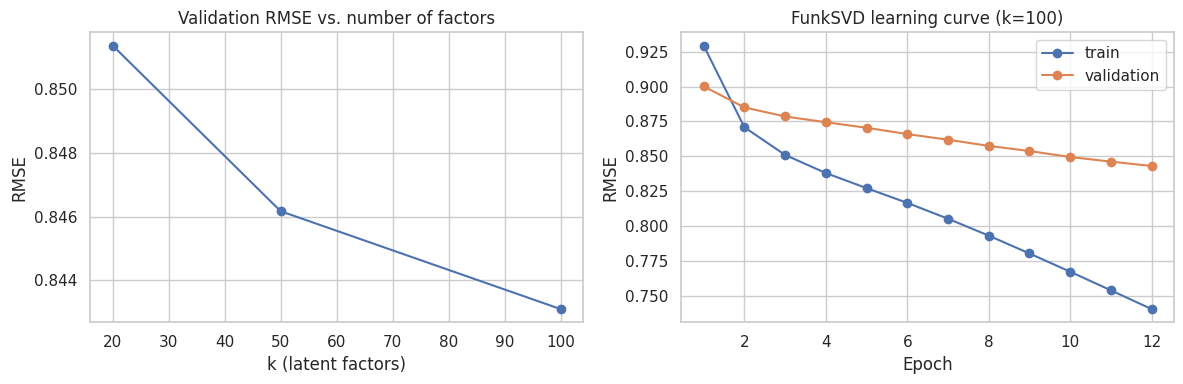

In [14]:
ks = list(tuned)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, [tuned[k].history["val_rmse"][-1] for k in ks], marker="o")
axes[0].set(title="Validation RMSE vs. number of factors",
            xlabel="k (latent factors)", ylabel="RMSE")

h = tuned[best_k].history
axes[1].plot(range(1, len(h["train_rmse"]) + 1), h["train_rmse"], marker="o", label="train")
axes[1].plot(range(1, len(h["val_rmse"]) + 1), h["val_rmse"], marker="o", label="validation")
axes[1].set(title=f"FunkSVD learning curve (k={best_k})", xlabel="Epoch", ylabel="RMSE")
axes[1].legend()
plt.tight_layout()
plt.show()

Unlike v1, the error now **decreases** during training and flattens out. The widening gap
between the curves is the (regularized) generalization gap — more epochs would keep lowering
train RMSE while validation RMSE stalls, which is exactly what the validation curve is for.

## 8. Final rating-prediction results on the test set

The final CF model is retrained on train+validation with the chosen `k`; the baselines are
refit the same way. The test set is used only here.

In [15]:
cf_final = FunkSVD(n_factors=best_k, n_epochs=20).fit(train_val)

rows = {name: rmse(test["rating"], predict(test))
        for name, predict in fit_baselines(train_val).items()}
rows[f"FunkSVD (k={best_k})"] = rmse(test["rating"], cf_final.predict_df(test))
results_rmse = pd.Series(rows, name="test RMSE").round(4).to_frame()
results_rmse

,test RMSE
Global mean,1.0449
User mean,0.9640
Item mean,0.9398
Bias model (mu+bu+bi),0.8649
FunkSVD (k=100),0.8200


## 9. Content-based model on genres (fixed TF-IDF)

v1's default tokenizer split `Sci-Fi` → `sci`,`fi` and `Film-Noir` → `film`,`noir`, and turned
`(no genres listed)` into the fake tokens `genres`,`listed` (`no` was swallowed by the English
stop-word list) — 23 features instead of 19. Here each `|`-separated genre is one token and
`(no genres listed)` becomes an empty (all-zero) vector.

In [16]:
movies["genre_list"] = movies["genres"].apply(
    lambda g: [] if g == "(no genres listed)" else g.split("|"))

tfidf = TfidfVectorizer(analyzer=lambda genre_list: genre_list)
G = tfidf.fit_transform(movies["genre_list"])       # sparse (n_movies x n_genres)
Gd = np.asarray(G.todense())                        # small enough to densify: 9742 x 19

movie_row = pd.Series(movies.index, index=movies["movieId"])   # movieId -> row of G / movies
print("TF-IDF matrix:", G.shape)
print("vocabulary:", sorted(tfidf.vocabulary_))

TF-IDF matrix: (7359, 19)
vocabulary: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


A quick "movies like X" check — the seed movie is **excluded from its own results** and ties
(many movies share the exact same genre set) are broken by popularity. The similarity row is
computed on demand instead of materializing the 9,742 × 9,742 matrix (~760 MB) like v1 did.

In [17]:
num_ratings_all = ratings.groupby("movieId").size()


def similar_movies(title, top_n=10):
    hits = movies.index[movies["title"] == title]
    if len(hits) == 0:
        close = movies.loc[movies["title"].str.contains(title, case=False, regex=False),
                           "title"].head(5).tolist()
        raise ValueError(f"'{title}' not found. Close matches: {close}")
    idx = hits[0]
    out = movies[["movieId", "title", "genres"]].copy()
    out["similarity"] = cosine_similarity(G[idx], G).ravel()
    out["num_ratings"] = out["movieId"].map(num_ratings_all).fillna(0).astype(int)
    return (out.drop(index=idx)
               .sort_values(["similarity", "num_ratings"], ascending=[False, False])
               .head(top_n).reset_index(drop=True))


similar_movies("Toy Story (1995)")

,movieId,title,genres,similarity,num_ratings
0,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.000000,661
1,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.000000,660
2,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.000000,295
3,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.000000,175
4,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.000000,60
5,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.000000,48
6,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,1.000000,12
7,2116,"Lord of the Rings, The (1978)",Adventure|Animation|Children|Fantasy,0.964211,137
8,4366,Atlantis: The Lost Empire (2001),Adventure|Animation|Children|Fantasy,0.964211,77
9,4519,"Land Before Time, The (1988)",Adventure|Animation|Children|Fantasy,0.964211,58


## 10. From similarities to personal rankers

Instead of anchoring on a single seed movie (v1), each user gets a **genre profile**: the sum
of the genre vectors of the movies they rated, weighted by `rating − 2.5` (the midpoint of the
0.5–5 scale), so disliked genres push the profile *away*. Content scores are cosine
similarities between the profile and every movie.

Every ranker is expressed as a user × movie **score matrix** over the full catalog, so they
can be blended and evaluated identically:

* **Popularity** — number of ratings in the fit set (identical order for every user, a sanity baseline);
* **Content** — cosine(user genre profile, movie genres);
* **CF** — FunkSVD predicted rating (catalog items unseen at fit time fall back to $\mu + b_u$);
* **Hybrid(α)** — α·CF + (1−α)·Content, after per-user min–max normalization of each side.

In [18]:
def user_order(model):
    return np.array(sorted(model.u_map, key=model.u_map.get))


def content_matrix(model, fit_df):
    """(n_users x n_catalog) cosine similarity between user genre profiles and all movies."""
    rows = fit_df["userId"].map(model.u_map).to_numpy()
    cols = fit_df["movieId"].map(movie_row).to_numpy()
    w = fit_df["rating"].to_numpy() - 2.5
    W = sparse.csr_matrix((w, (rows, cols)), shape=(len(model.u_map), len(movies)))
    prof = W @ Gd                                                   # (n_users x n_genres)
    norm = np.linalg.norm(prof, axis=1, keepdims=True)
    norm[norm == 0] = 1.0
    item_norm = np.linalg.norm(Gd, axis=1, keepdims=True)
    item_norm[item_norm == 0] = 1.0
    return ((prof / norm) @ (Gd / item_norm).T).astype(np.float32)


def cf_matrix(model):
    """(n_users x n_catalog) FunkSVD scores; items unseen at fit time get mu + b_u."""
    S = (np.full((len(model.u_map), len(movies)), model.mu)
         + model.bu[:, None]).astype(np.float32)
    items = np.array(sorted(model.i_map, key=model.i_map.get))
    known = model.mu + model.bu[:, None] + model.bi[None, :] + model.P @ model.Q.T
    S[:, movie_row[items].to_numpy()] = known
    return np.clip(S, 0.5, 5.0)


def popularity_matrix(model, fit_df):
    pop = np.zeros(len(movies))
    counts = fit_df.groupby("movieId").size()
    pop[movie_row[counts.index].to_numpy()] = counts.to_numpy()
    return np.tile(pop.astype(np.float32), (len(model.u_map), 1))


def minmax_rows(S):
    lo = S.min(axis=1, keepdims=True)
    hi = S.max(axis=1, keepdims=True)
    return (S - lo) / np.where(hi > lo, hi - lo, 1.0)


def hybrid_matrix(cf_S, ct_S, alpha):
    return alpha * minmax_rows(cf_S) + (1 - alpha) * minmax_rows(ct_S)

## 11. Top-N evaluation protocol

For every user we rank the catalog **excluding movies they rated in the fit set**, take the
top 10, and compare against the movies they rated **≥ 4.0** in the held-out set:

* **Precision@10** — fraction of recommended movies that are relevant;
* **Recall@10** — fraction of the user's relevant movies that got recommended;
* **NDCG@10** — rank-aware: hits near the top of the list count more;
* **Coverage** — share of the catalog appearing in anyone's top-10 (does the system recommend
  only blockbusters?).

Users with no relevant held-out movies are skipped, as is standard.

**A caveat on offline top-N metrics.** With a random held-out split, the "relevant"
items are drawn from what users actually chose to watch — which is itself heavily
popularity-biased. Raw popularity is therefore a deceptively strong baseline on these
metrics (Cremonesi et al., 2010), which is exactly why **coverage** is reported
alongside accuracy.

In [19]:
def evaluate_topn(score_M, model, fit_df, held_out, k=10, threshold=4.0):
    users = user_order(model)
    seen = fit_df.groupby("userId")["movieId"].apply(set)
    relevant = held_out[held_out["rating"] >= threshold].groupby("userId")["movieId"].apply(set)
    movie_ids = movies["movieId"].to_numpy()

    precs, recs, ndcgs, recommended = [], [], [], set()
    for row, uid in enumerate(users):
        rel = relevant.get(uid)
        if not rel:
            continue
        s = score_M[row].astype(float).copy()
        s[movie_row[list(seen.get(uid, ()))].to_numpy()] = -np.inf   # never re-recommend
        top = np.argpartition(-s, k)[:k]
        top = top[np.argsort(-s[top])]
        top_ids = movie_ids[top]

        hits = np.isin(top_ids, list(rel))
        precs.append(hits.sum() / k)
        recs.append(hits.sum() / len(rel))
        dcg = float((hits / np.log2(np.arange(2, k + 2))).sum())
        idcg = float((1 / np.log2(np.arange(2, min(len(rel), k) + 2))).sum())
        ndcgs.append(dcg / idcg)
        recommended.update(top_ids)

    return {"Precision@10": float(np.mean(precs)), "Recall@10": float(np.mean(recs)),
            "NDCG@10": float(np.mean(ndcgs)), "Coverage": len(recommended) / len(movies),
            "users evaluated": len(precs)}

## 12. Choosing α on the validation set

α = 1 → pure collaborative, α = 0 → pure content. v1 compared recommendation lists by eye;
here α is selected by validation NDCG@10, with the CF model fit on `train` only so
validation stays honest. The two score matrices are min–max normalized **once** and then
blended cheaply for each α.

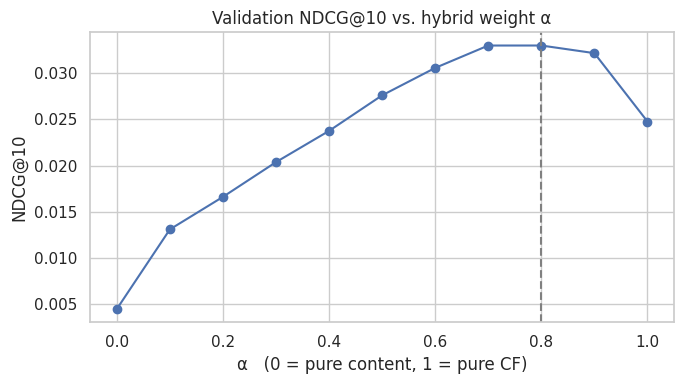

best α = 0.8


In [ ]:
cf_tuned = tuned[best_k]
cf_N_val = minmax_rows(cf_matrix(cf_tuned))
ct_N_val = minmax_rows(content_matrix(cf_tuned, train))

alphas = np.round(np.arange(0.0, 1.01, 0.1), 2)
ndcg_by_alpha = [
    evaluate_topn(a * cf_N_val + (1 - a) * ct_N_val, cf_tuned, train, val)["NDCG@10"]
    for a in alphas
]
best_alpha = float(alphas[int(np.argmax(ndcg_by_alpha))])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, ndcg_by_alpha, marker="o")
ax.axvline(best_alpha, ls="--", c="gray")
ax.set(title="Validation NDCG@10 vs. hybrid weight α",
       xlabel="α   (0 = pure content, 1 = pure CF)", ylabel="NDCG@10")
plt.tight_layout()
plt.show()
print(f"best α = {best_alpha}")
del cf_N_val, ct_N_val

## 13. Final top-N results on the test set

Everything is refit on train+validation; relevance comes from test ratings ≥ 4.
(Min–max normalization is monotone per user, so ranking the normalized CF/content
matrices is identical to ranking the raw ones.)

In [21]:
cf_N = minmax_rows(cf_matrix(cf_final))
ct_N = minmax_rows(content_matrix(cf_final, train_val))
pop_S = popularity_matrix(cf_final, train_val)

final_table = pd.DataFrame({
    "Popularity": evaluate_topn(pop_S, cf_final, train_val, test),
    "Content (genres)": evaluate_topn(ct_N, cf_final, train_val, test),
    f"CF — FunkSVD (k={best_k})": evaluate_topn(cf_N, cf_final, train_val, test),
    f"Hybrid (alpha={best_alpha})": evaluate_topn(
        best_alpha * cf_N + (1 - best_alpha) * ct_N, cf_final, train_val, test),
}).T
del pop_S
final_table.round(4)

,Precision@10,Recall@10,NDCG@10,Coverage,users evaluated
Popularity,0.0687,0.1097,0.1117,0.0126,3614.0
Content (genres),0.0039,0.0068,0.0052,0.5092,3614.0
CF — FunkSVD (k=100),0.0178,0.0229,0.0256,0.1402,3614.0
Hybrid (alpha=0.8),0.0219,0.0331,0.0359,0.1851,3614.0


## 14. Producing recommendations

The same machinery, packaged as a function. The demo user is picked programmatically
(the median-activity user of the subsample), since user ids differ from the small dataset.

In [22]:
users_final = user_order(cf_final)
user_pos = {u: k for k, u in enumerate(users_final)}
seen_final = train_val.groupby("userId")["movieId"].apply(set)


def recommend_for_user(user_id, alpha=None, top_n=10):
    if user_id not in user_pos:
        raise ValueError(f"User {user_id} not in the training data (cold start): "
                         "fall back to popularity or ask for a few initial ratings.")
    if alpha is None:
        alpha = best_alpha
    row = user_pos[user_id]
    score = alpha * cf_N[row] + (1 - alpha) * ct_N[row]
    s = score.astype(float)
    s[movie_row[list(seen_final.get(user_id, ()))].to_numpy()] = -np.inf
    top = np.argsort(-s)[:top_n]
    out = movies.loc[top, ["title", "genres"]].copy()
    out["cf"] = np.round(cf_N[row][top].astype(float), 3)
    out["content"] = np.round(ct_N[row][top].astype(float), 3)
    out["hybrid"] = np.round(score[top].astype(float), 3)
    return out.reset_index(drop=True)


activity = train_val["userId"].value_counts()
demo_user = int(activity.index[len(activity) // 2])
print(f"demo user: {demo_user}  ({activity[demo_user]} ratings in train+val)")

for a in sorted({0.0, best_alpha, 1.0}):
    label = " (tuned)" if a == best_alpha else ""
    print(f"\n=== User {demo_user} — top 10 with alpha = {a}{label} ===")
    display(recommend_for_user(demo_user, alpha=a))

demo user: 113342  (61 ratings in train+val)

=== User 113342 — top 10 with alpha = 0.0 ===


,title,genres,cf,content,hybrid
0,"Lovely Bones, The (2009)",Crime|Drama|Fantasy|Horror|Thriller,0.733,1.000,1.000
1,"Exorcism of Emily Rose, The (2005)",Crime|Drama|Horror|Thriller,0.703,0.993,0.993
2,"Hole, The (2001)",Crime|Drama|Horror|Mystery|Thriller,0.620,0.983,0.983
3,Manhunter (1986),Action|Crime|Drama|Horror|Thriller,0.653,0.979,0.979
4,1408 (2007),Drama|Horror|Thriller,0.644,0.971,0.971
5,Dark Water (2005),Drama|Horror|Thriller,0.358,0.971,0.971
6,Dead Ringers (1988),Drama|Horror|Thriller,0.681,0.971,0.971
7,Mary Reilly (1996),Drama|Horror|Thriller,0.403,0.971,0.971
8,Ginger Snaps (2000),Drama|Horror|Thriller,0.699,0.971,0.971
9,Carriers (2009),Drama|Horror|Thriller,0.678,0.971,0.971



=== User 113342 — top 10 with alpha = 0.8 (tuned) ===


,title,genres,cf,content,hybrid
0,Fight Club (1999),Action|Crime|Drama|Thriller,1.000,0.800,0.960
1,"Testament of Dr. Mabuse, The (Das Testament de...",Crime|Horror|Mystery|Thriller,0.927,0.890,0.920
2,"Vanishing, The (Spoorloos) (1988)",Drama|Thriller,0.912,0.815,0.893
3,Donnie Darko (2001),Drama|Mystery|Sci-Fi|Thriller,0.936,0.694,0.887
4,Witness for the Prosecution (1957),Drama|Mystery|Thriller,0.918,0.743,0.883
5,"Cranes Are Flying, The (Letyat zhuravli) (1957)",Drama|Romance|War,1.000,0.390,0.878
6,Rope (1948),Crime|Drama|Thriller,0.890,0.816,0.876
7,Elite Squad (Tropa de Elite) (2007),Action|Crime|Drama|Thriller,0.893,0.800,0.875
8,Santa Sangre (1989),Drama|Horror|Mystery|Thriller,0.859,0.933,0.874
9,"Godfather, The (1972)",Crime|Drama,0.957,0.527,0.871



=== User 113342 — top 10 with alpha = 1.0 ===


,title,genres,cf,content,hybrid
0,Fight Club (1999),Action|Crime|Drama|Thriller,1.000,0.800,1.000
1,"Cranes Are Flying, The (Letyat zhuravli) (1957)",Drama|Romance|War,1.000,0.390,1.000
2,Ivan's Childhood (a.k.a. My Name is Ivan) (Iva...,Drama|War,0.969,0.335,0.969
3,Who's Afraid of Virginia Woolf? (1966),Drama,0.967,0.475,0.967
4,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,0.965,0.184,0.965
5,Fitzcarraldo (1982),Adventure|Drama,0.960,0.422,0.960
6,"Nights of Cabiria (Notti di Cabiria, Le) (1957)",Drama,0.959,0.475,0.959
7,"Godfather, The (1972)",Crime|Drama,0.957,0.527,0.957
8,Steam of Life (Miesten vuoro) (2010),Documentary,0.955,0.000,0.955
9,Rififi (Du rififi chez les hommes) (1955),Crime|Film-Noir|Thriller,0.954,0.398,0.954


With α = 0 the list is dominated by the user's favorite genres; with α = 1 it follows
collaborative taste patterns; the tuned α blends both. Previously watched movies are
excluded by construction.

## 15. Summary, limitations, future work

In [23]:
print(f"Data: {len(ratings):,} ratings | {N_USERS:,} users | {len(movies):,} movies "
      f"(subsampled from 20,000,263 / 138,493 / 27,278; SEED={SEED})")
print("\nRating prediction — test RMSE")
print(results_rmse.to_string())
print(f"\n(The v1 zero-filled SVD approach scored ≈ {rmse(v['rating'], v1_preds):.2f} "
      f"on validation — see section 5.)")
print(f"\nChosen hyperparameters: k = {best_k}, alpha = {best_alpha}")
print("\nTop-10 ranking — test")
print(final_table.round(4).to_string())

Data: 568,926 ratings | 4,000 users | 7,359 movies (subsampled from 20,000,263 / 138,493 / 27,278; SEED=42)

Rating prediction — test RMSE
                       test RMSE
Global mean               1.0449
User mean                 0.9640
Item mean                 0.9398
Bias model (mu+bu+bi)     0.8649
FunkSVD (k=100)           0.8200

(The v1 zero-filled SVD approach scored ≈ 2.86 on validation — see section 5.)

Chosen hyperparameters: k = 100, alpha = 0.8

Top-10 ranking — test
                      Precision@10  Recall@10  NDCG@10  Coverage  users evaluated
Popularity                  0.0687     0.1097   0.1117    0.0126           3614.0
Content (genres)            0.0039     0.0068   0.0052    0.5092           3614.0
CF — FunkSVD (k=100)        0.0178     0.0229   0.0256    0.1402           3614.0
Hybrid (alpha=0.8)          0.0219     0.0331   0.0359    0.1851           3614.0


**Takeaways.**
* With 5.6× more ratings than the small dataset, the *same* FunkSVD pipeline improves from test RMSE 0.873 (v2, `ml-latest-small`) to **0.820**, and the best capacity grows from k = 30 to k = 100 — a textbook illustration that more data supports more latent factors. Every baseline is beaten (global mean 1.045, best baseline 0.865).
* The tuned hybrid (α = 0.8) again beats both of its components on Precision@10, Recall@10 and NDCG@10, and it recommends from 18.5% of the catalog (~1,360 distinct movies) versus the popularity baseline's 1.3% (~90 movies).
* Raw popularity still tops the accuracy@10 metrics — the offline popularity-bias artifact discussed in section 11 (Cremonesi et al., 2010). That is exactly why coverage is reported alongside accuracy, and why ranking-optimized objectives are the natural next step below.

**Limitations.**
* Results are for one random subsample of `N_USERS = 4,000` users (SEED = 42). A different
  seed or a larger `N_USERS` shifts the numbers slightly; the *ordering* of methods is
  stable in our runs. Training on the full 20M would require a vectorized solver
  (ALS, or libraries like `implicit`/`LightFM`) instead of per-sample SGD in Python.
* Genres are a coarse content signal (19 tags); many movies share identical genre vectors,
  so a pure content ranker has many ties and limited personalization depth.
* The random split lets models "see the future"; a temporal split (train on the past,
  test on later ratings) is more realistic — timestamps are loaded and ready for this.
* Offline metrics undervalue good recommendations the user simply never encountered, and
  (section 11) they reward popularity.

**Future work.**
* **Tag genome (in this same archive).** `genome_scores.csv` gives a 1,128-dimensional
  tag-relevance vector for ~10k movies — a drop-in, far richer replacement for the
  19-genre content model.
* Ranking-optimized objectives (BPR, implicit-feedback MF) to close the top-N gap to the
  popularity baseline; item-KNN and ALS comparisons.
* Temporal evaluation split; cold-start onboarding; a small Streamlit demo.

---
*Dataset: F. M. Harper & J. A. Konstan (2015), "The MovieLens Datasets: History and
Context," ACM TiiS 5(4). MovieLens 20M downloaded via Kaggle; used for
research/educational purposes.*